In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

print("Semua library berhasil")

Semua library berhasil


In [54]:
import os

# Lokasi folder dataset
dataset_path = "flowers"

# Nama kelas bunga
classes = os.listdir(dataset_path)

print("Jumlah kelas :", len(classes))
print("Nama kelas :", classes)

Jumlah kelas : 5
Nama kelas : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


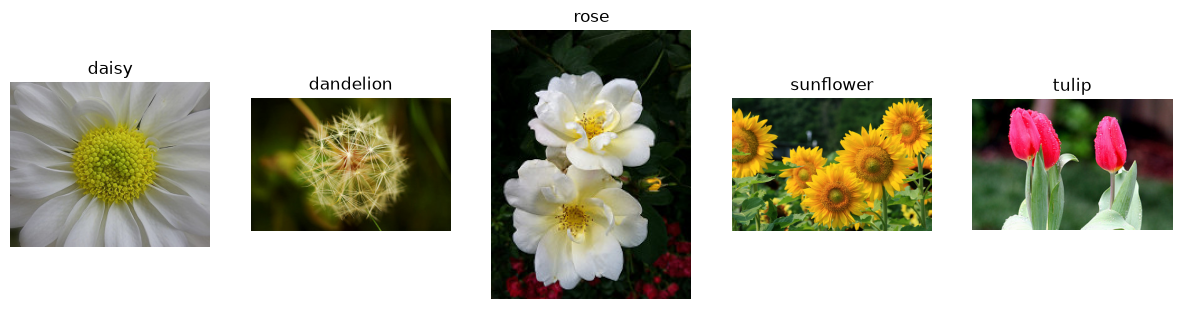

In [55]:
import matplotlib.pyplot as plt
import cv2
import os

# Menampilkan 1 gambar dari setiap kelas
plt.figure(figsize=(15,5))

for i, folder in enumerate(classes):
    folder_path = os.path.join(dataset_path, folder)

    image_name = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")

plt.show()

In [56]:
import numpy as np
import cv2
import os

X = []
y = []

# Ukuran gambar
IMG_SIZE = 64

for folder in classes:
    folder_path = os.path.join(dataset_path, folder)

    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)

        image = cv2.imread(image_path)

        if image is not None:
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = image.astype("float32") / 255.0
            image = image.flatten()

            X.append(image)
            y.append(folder)

# Mengubah ke array numpy
X = np.array(X)
y = np.array(y)

print("Jumlah data :", len(X))
print("Ukuran setiap gambar :", X.shape)

Jumlah data : 4317
Ukuran setiap gambar : (4317, 12288)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=24146035
)

print("Data Training :", X_train.shape)
print("Data Testing :", X_test.shape)

Data Training : (3453, 12288)
Data Testing : (864, 12288)


In [58]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=24146035
)

mlp.fit(X_train, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


In [59]:
y_pred = mlp.predict(X_test)

print("Prediksi selesai")

Prediksi selesai


In [60]:
from sklearn.metrics import accuracy_score, classification_report

akurasi = accuracy_score(y_test, y_pred)

print("Accuracy :", akurasi)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy : 0.4756944444444444

Classification Report

              precision    recall  f1-score   support

       daisy     0.4766    0.3036    0.3709       168
   dandelion     0.5298    0.6681    0.5910       226
        rose     0.3795    0.4868    0.4265       152
   sunflower     0.5591    0.5420    0.5504       131
       tulip     0.4267    0.3422    0.3798       187

    accuracy                         0.4757       864
   macro avg     0.4743    0.4686    0.4637       864
weighted avg     0.4751    0.4757    0.4674       864



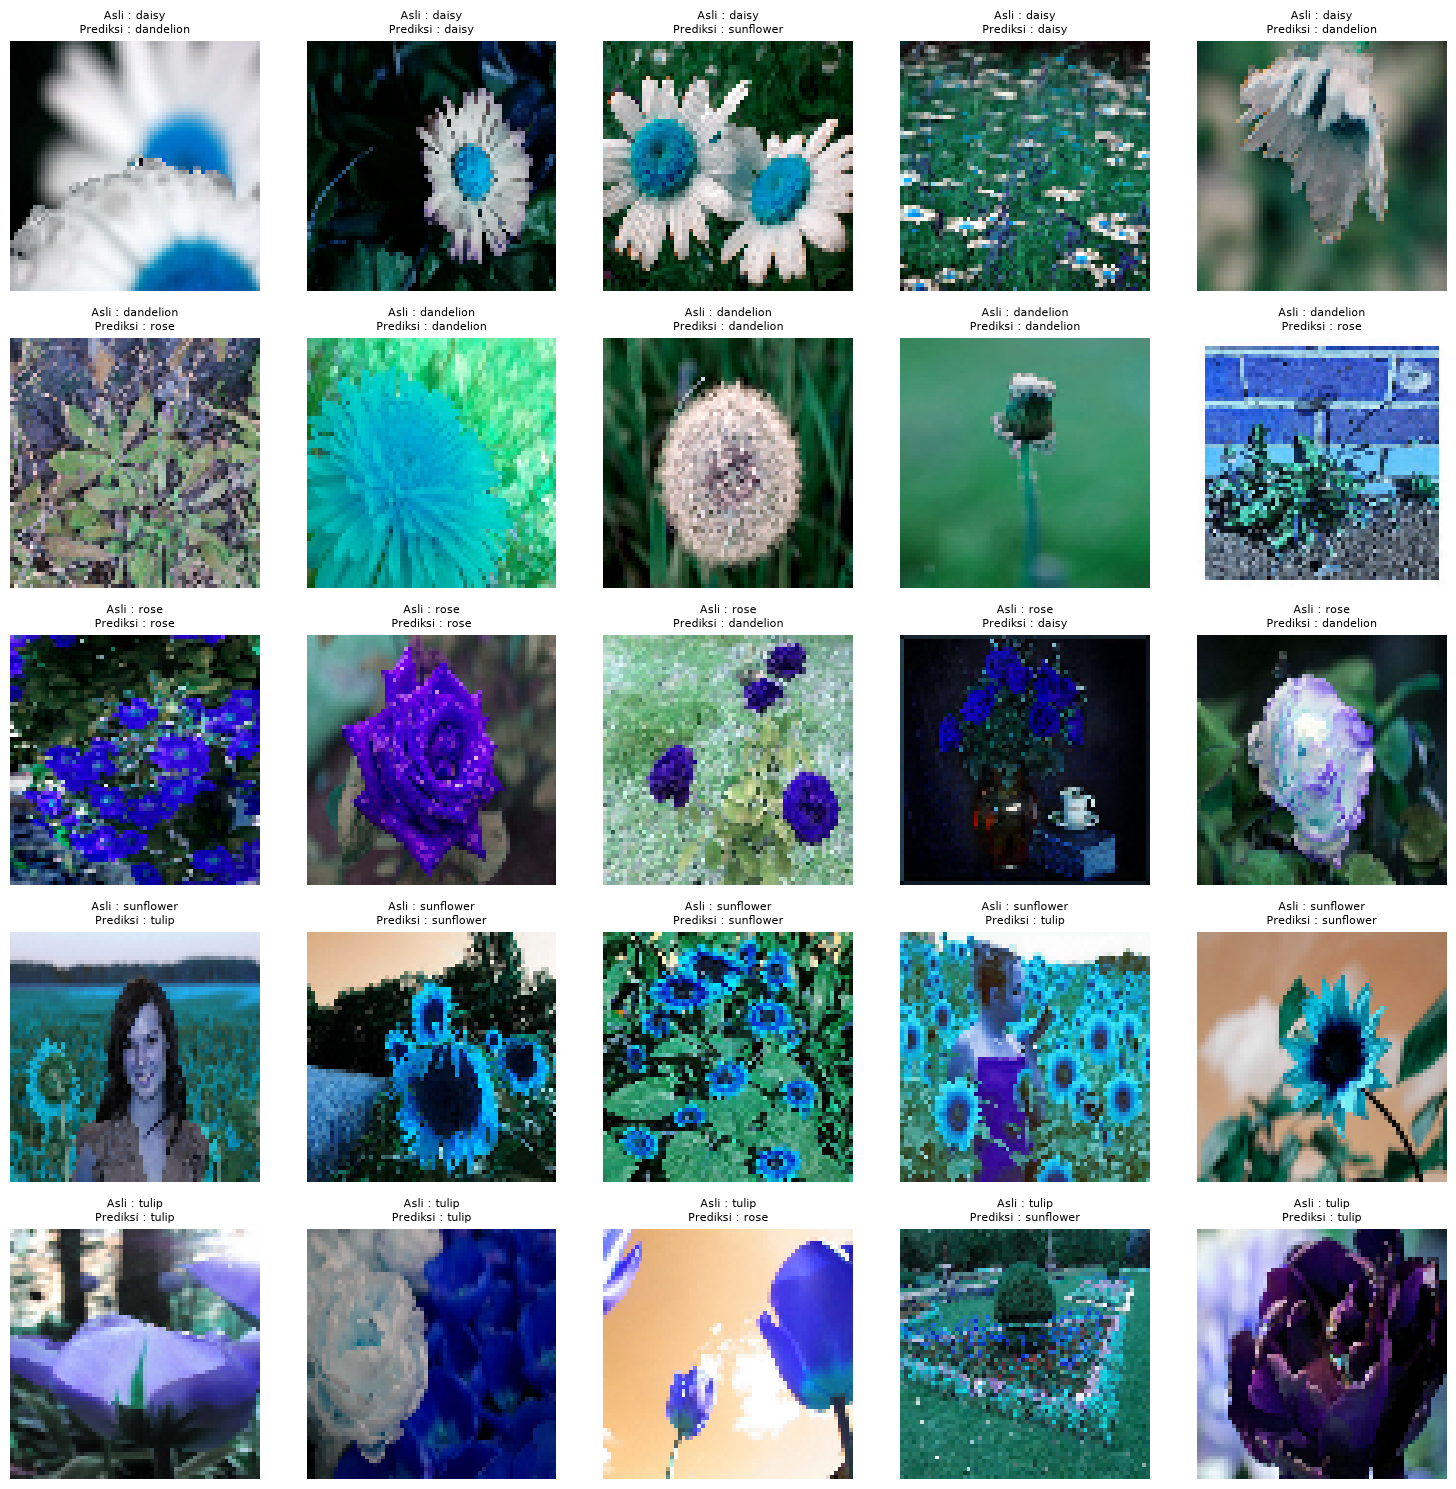

In [61]:
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))

plot_number = 1

for kelas in classes:
    # Ambil indeks gambar sesuai kelas
    idx = np.where(y_test == kelas)[0]

    # Pilih maksimal 5 gambar secara acak
    sample_idx = random.sample(list(idx), min(5, len(idx)))

    for i in sample_idx:
        gambar = X_test[i].reshape(64,64,3)

        prediksi = mlp.predict([X_test[i]])[0]

        plt.subplot(5,5,plot_number)
        plt.imshow(gambar)
        plt.title(f"Asli : {kelas}\nPrediksi : {prediksi}", fontsize=8)
        plt.axis("off")

        plot_number += 1

plt.tight_layout()
plt.show()